In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATA_ROOT = './data'

In [3]:
#logTPM_res = pd.read_csv(f'{DATA_ROOT}/MSE_results_logTPM.csv', index_col = 0)
TPM_res = pd.read_csv(f'{DATA_ROOT}/MSE_results_TPM.csv', index_col = 0, header = 0)
external_res = pd.read_csv(f'{DATA_ROOT}/external_MSE_TPM.csv', index_col= 0, header = 0)
merged_results = pd.read_csv(f'{DATA_ROOT}/TPM_res_in_features.csv', index_col= 0, header = 0)

In [4]:
TPM_res

,train_score,test_score
A2M,4.543514,4.550996
A2ML1,0.466641,0.468028
A3GALT2,0.013694,0.015116
A4GALT,0.133942,0.134081
AAAS,0.134521,0.130718
...,...,...
ZYG11A,0.125508,0.117610
ZYG11B,0.109539,0.117292
ZYX,0.287542,0.295986
ZZEF1,0.094320,0.094426


In [5]:
merged_results

,train_score,test_score,in_features
A2M,4.543514,4.550996,13
A2ML1,0.466641,0.468028,1
A3GALT2,0.013694,0.015116,49
A4GALT,0.133942,0.134081,80
AAAS,0.134521,0.130718,121
...,...,...,...
ZYG11A,0.125508,0.117610,67
ZYG11B,0.109539,0.117292,58
ZYX,0.287542,0.295986,133
ZZEF1,0.094320,0.094426,97


In [6]:
TPM_res.loc[TPM_res['test_score'] < 0.2, :].shape[0]

10491

In [7]:
#log_to_plot = pd.melt(logTPM_res)
TPM_to_plot = pd.melt(TPM_res)

In [8]:
#create function make train test MSE violin plot
def loss_violin_plot(df, palette, title, figtitle):
    fig, ax = plt.subplots()
    ax = sns.violinplot(data = df, x = 'variable', y="value", hue = 'variable', palette=palette)
    ax.set_ylabel('MSE', fontsize = 15)
    ax.set_xlabel('Dataset', fontsize = 15)
    fig.canvas.draw()
    labels = [item.get_text() for item in ax.get_xticklabels()]
    labels[0], labels[1] = ['Training', 'Test']
    ax.set_xticklabels(['Training', 'Test'], fontsize = 10)
    fig.suptitle(title, fontsize = 20)
    plt.savefig(figtitle, dpi = 300)

/var/folders/31/nm2_1xn55zl20tj7l_p3rzb40000gn/T/ipykernel_3018/1421562481.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Training', 'Test'], fontsize = 10)


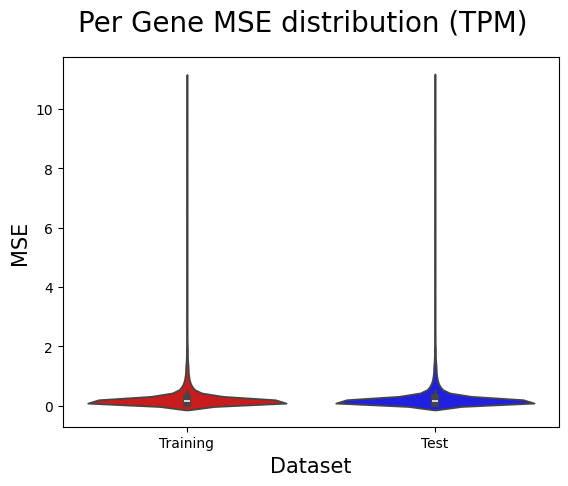

In [9]:
loss_violin_plot(TPM_to_plot, palette=['#e60000', '#0000ff'], title ='Per Gene MSE distribution (TPM)', figtitle= 'figures/TPM_train_test')

# External dataset erorr scores

In [ ]:
merged_results.loc[merged_results['TPM_ext_diff'] > 0.5].shape

(5313, 5)

Text(0.5, 1.0, 'Distribution of model sizes')

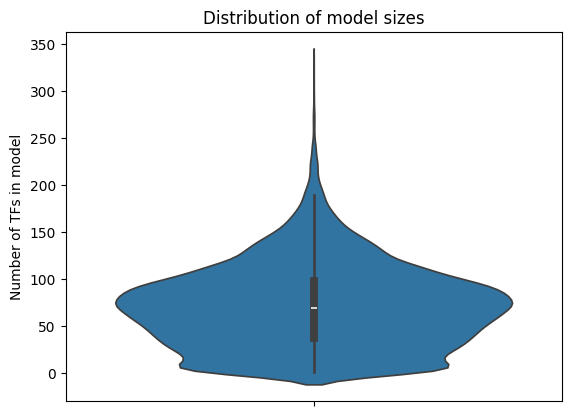

In [12]:
sns.violinplot(merged_results['in_features'])
plt.ylabel('Number of TFs in model')
plt.title('Distribution of model sizes')

In [13]:
merged_results['external_res'] = external_res['external_set_score']

In [ ]:
merged_results['log_external'] = np.log(merged_results['external_res'] + 1)

In [16]:
merged_results


,train_score,test_score,in_features,external_res,log_external
A2M,4.543514,4.550996,13,245.972473,5.509277
A2ML1,0.466641,0.468028,1,1.292142,0.829487
A3GALT2,0.013694,0.015116,49,0.007396,0.007369
A4GALT,0.133942,0.134081,80,0.042194,0.041329
AAAS,0.134521,0.130718,121,0.115285,0.109110
...,...,...,...,...,...
ZYG11A,0.125508,0.117610,67,0.025949,0.025618
ZYG11B,0.109539,0.117292,58,1.349291,0.854113
ZYX,0.287542,0.295986,133,0.746363,0.557535
ZZEF1,0.094320,0.094426,97,0.540941,0.432393


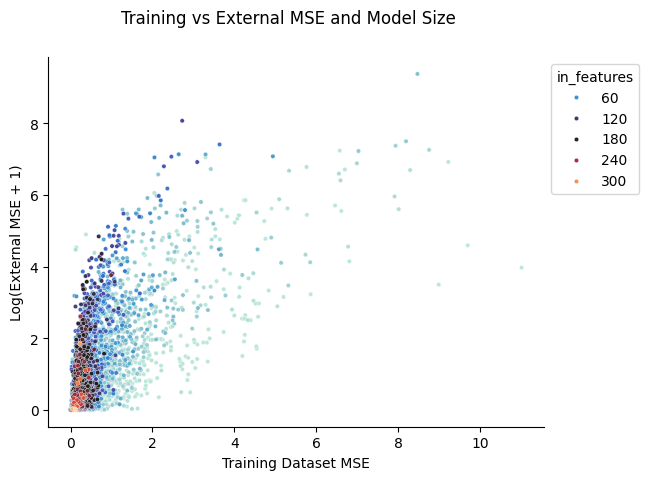

In [20]:
fig, ax = plt.subplots(ncols=1)

sorted_results = merged_results.sort_values('in_features')
sns.scatterplot(data=sorted_results, x = 'train_score', y = 'log_external', legend=True, ax = ax, hue = 'in_features', palette='icefire', s=10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine()
ax.set_xlabel('Training Dataset MSE', fontsize = 10)
ax.set_ylabel('Log(External MSE + 1)', fontsize = 10)
fig.suptitle('Training vs External MSE and Model Size')
plt.savefig('figures/trainVSextVSModel', bbox_inches='tight')

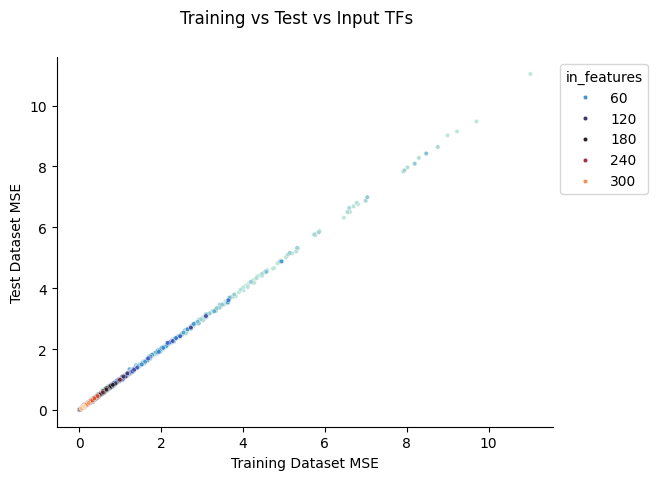

In [18]:
fig, ax = plt.subplots(ncols=1)

sorted_results = merged_results.sort_values('in_features')
sns.scatterplot(data=sorted_results, x = 'train_score', y = 'test_score', legend=True, ax = ax, hue = 'in_features', palette='icefire', s=10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine()
ax.set_xlabel('Training Dataset MSE', fontsize = 10)
ax.set_ylabel('Test Dataset MSE', fontsize = 10)
fig.suptitle('Training vs Test vs Input TFs')
plt.savefig('figures/trainVsTestvsModel', bbox_inches='tight')

In [ ]:
external_res.loc[external_res['external_set_score'] < 1].shape

(13446, 2)

In [ ]:
external_res['log'] = np.log(external_res['external_set_score'] + 1)

/var/folders/31/nm2_1xn55zl20tj7l_p3rzb40000gn/T/ipykernel_88664/1795373650.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data = external_res, y="log", palette=['#e60000'])


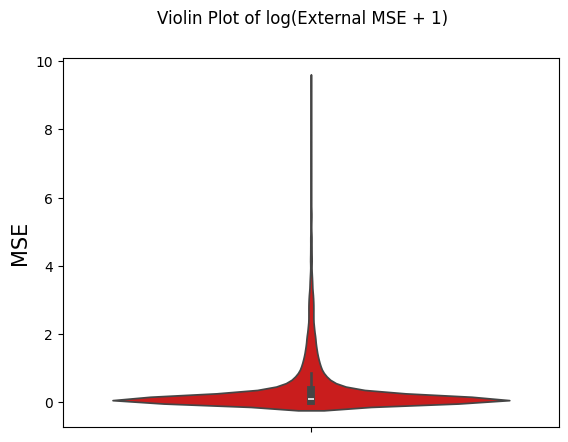

In [ ]:
fig, ax = plt.subplots()
ax = sns.violinplot(data = external_res, y="log", palette=['#e60000'])
ax.set_ylabel('MSE', fontsize = 15)
fig.suptitle('Violin Plot of log(External MSE + 1)')
plt.show()
#ax.set_xlabel('Dataset', fontsize = 15)
#fig.canvas.draw()
#labels = [item.get_text() for item in ax.get_xticklabels()]
#labels[0], labels[1] = ['Training', 'Test']
#ax.set_xticklabels(['Training', 'Test'], fontsize = 10)
#fig.suptitle(title, fontsize = 20)
#plt.savefig(figtitle, dpi = 300)